## EXAMPLE SCRIPT

#### Read files in the project folder

In [ ]:
# Option 1 no export subfolder
from pathlib import Path
import os

SCRIPT_FOLDER = Path(r"C:\Path\to\Datamine_Python_Scripts\File_classifier_organiser_202605")
INPUT_FOLDER  = Path(r"C:\Database\Project")

SUMMARY_SCRIPT = SCRIPT_FOLDER / "datamine_dm_legacy_reader_working.py"
CLASSIFIER_SCRIPT = SCRIPT_FOLDER / "datamine_file_classifier_working.py"
ORGANISER_SCRIPT  = SCRIPT_FOLDER / "datamine_file_organiser_working.py"

SUMMARY_OUT = INPUT_FOLDER / "dm_file_summary.csv"
CLASSIFIED_OUT = INPUT_FOLDER / "dm_file_summary_classified.csv"

CLASSIFIED_FOR_ORGANISER = INPUT_FOLDER / "dm_file_summary_classified_for_organiser.csv"
SORTED_OUTPUT = INPUT_FOLDER / "sorted_output"



In [ ]:
# Option 2: add export subfolder

from pathlib import Path
import os

SCRIPT_FOLDER = Path(r"C:\Path\to\Datamine_Python_Scripts\File_classifier_organiser_202605")
INPUT_FOLDER  = Path(r"C:\Database\TEST_Project")

IF you want to

#os.mkdir(INPUT_FOLDER / "exports") I f export folder does not exist use this in the first run
EXPORT_FOLDER = Path(r"C:\Database\Project\exports")

SUMMARY_SCRIPT = SCRIPT_FOLDER / "datamine_dm_legacy_reader_working.py"
CLASSIFIER_SCRIPT = SCRIPT_FOLDER / "datamine_file_classifier_working.py"
ORGANISER_SCRIPT  = SCRIPT_FOLDER / "datamine_file_organiser_working.py"

SUMMARY_OUT = EXPORT_FOLDER / "dm_file_summary.csv"
CLASSIFIED_OUT = EXPORT_FOLDER / "dm_file_summary_classified.csv"

CLASSIFIED_FOR_ORGANISER = EXPORT_FOLDER / "dm_file_summary_classified_for_organiser.csv"
SORTED_OUTPUT = EXPORT_FOLDER / "sorted_output"



In [ ]:
!python "{SUMMARY_SCRIPT}" batch-summary "{INPUT_FOLDER}" --recursive --out "{SUMMARY_OUT}"

In [ ]:
import pandas as pd

summary = pd.read_csv(SUMMARY_OUT)
summary[["file", "extension", "summary_file_kind", "status", "columns"]].head(50)


#### Classify files and create a catalog

In [ ]:
!python "{CLASSIFIER_SCRIPT}" "{SUMMARY_OUT}" --out "{CLASSIFIED_OUT}"

Check files for errors and random files

In [ ]:
classified = pd.read_csv(CLASSIFIED_OUT)

classified[[
    "file",
    "final_detected_type",
    "final_suggested_folder",
    "confidence",
    "status"
]].head(30)  # or tail to see the end of the list


In [ ]:
Check unknown files for errors and random files

In [ ]:
unknown = classified[classified["final_suggested_folder"] == "99_Unknown"]

unknown[[
    "file",
    "extension",
    "columns",
    "final_detected_type",
    "final_suggested_folder",
    "decision_basis"
]]


most of the unclassified are tongrad files but the collars seems to be unclasified- need to check code.

#### Sort files into Subfolders

In [ ]:
classified = pd.read_csv(CLASSIFIED_OUT)
classified["suggested_folder"] = classified["final_suggested_folder"]
classified["detected_type"] = classified["final_detected_type"]
classified.to_csv(CLASSIFIED_FOR_ORGANISER, index=False)

!python "{ORGANISER_SCRIPT}" "{CLASSIFIED_FOR_ORGANISER}" "{SORTED_OUTPUT}" --include-unknown --min-confidence 0.0 --preserve-relative --source-root "{INPUT_FOLDER}"

This is a dry run that creates the  folder structure and puts fikles in.  It is essentially the same as copy so if you do not want to move the files you can stop at this point.

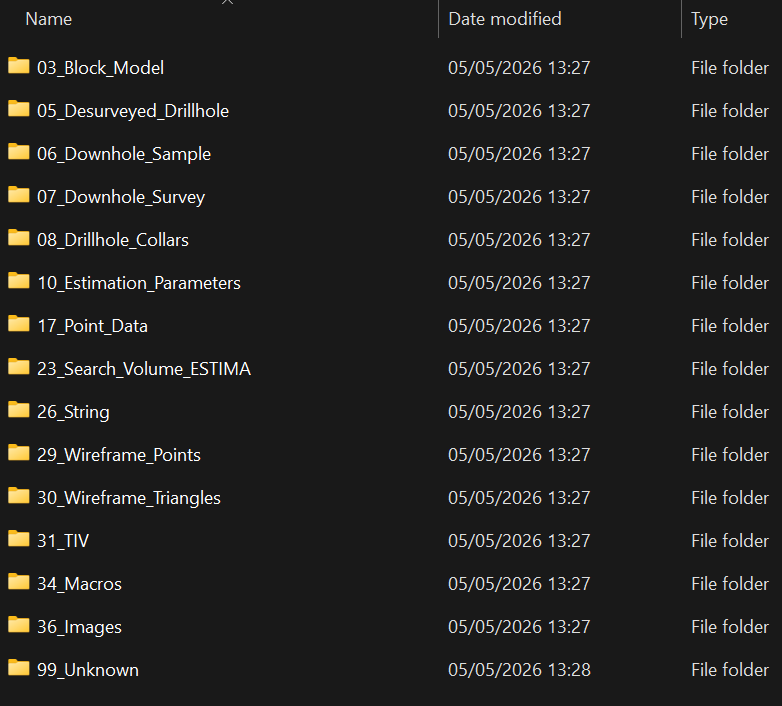
